# Libya — Sirte basin + coastal terminals — pyflare quickstart

> A 5-minute walkthrough: from the World Bank's annual GGFR
> estimates to a peer-reviewable CO₂-equivalent headline number
> for Libya's gas flaring. Runs without EOG credentials by
> using a synthetic VNF detection set for the region — replace
> the synthetic block with `pf.fetch_vnf_nightly()` once your
> EOG license + Client ID are in place.

**Why this country:** Libyan flaring is split between the Sirte basin and coastal export terminals. Despite political instability, Libya ranks just behind Nigeria in 2024 (6.28 bcm).

**Status:** validated against pyflare v0.1.0 + 2025 GGFR release
(data through 2024).


## Setup

```bash
pip install pyflare-africa[viz,notebooks]   # or `pip install -e ".[viz,notebooks]"` if developing
```

This notebook assumes `matplotlib` is available; everything else
is in pyflare's core install.


## Data attribution

This notebook is structured around the VIIRS Nightfire (VNF)
product. The synthetic VNF block in §3 is a stand-in until your
EOG academic license + Client ID are in place. **When you swap
that block for `pf.fetch_vnf_nightly()`, the following
attribution applies to every chart and table rendered below it:**

> This product was made utilizing VIIRS Nightfire (VNF) nightly
> data produced by the Earth Observation Group, Payne Institute
> for Public Policy, Colorado School of Mines.

For tight space, use: *"Source: VIIRS Nightfire, Colorado School
of Mines."*

See [`LICENSING_NOTES.md`](../LICENSING_NOTES.md) for the full
set of VNF license obligations.


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyflare as pf
from pyflare.analysis import (
    classify_detection_type,
    aggregate_to_sites,
    estimate_flared_volume,
    volume_to_co2eq,
)

print(f"pyflare {pf.__version__}")


pyflare 0.1.0


## 1. Annual flaring trend, Libya 2012–2024

`fetch_ggfr_annual()` pulls the live World Bank GGFR workbook,
melts it to long format, and normalises country names. No
authentication required.


In [2]:
annual = pf.fetch_ggfr_annual()
country_df = annual[annual["country"] == "Libya"].sort_values("year")
country_df.tail(8).reset_index(drop=True)


,country,year,bcm_flared
0,Libya,2017,3.908465
1,Libya,2018,4.682123
2,Libya,2019,5.124060
3,Libya,2020,2.473687
4,Libya,2021,5.998538
5,Libya,2022,5.420488
6,Libya,2023,6.801338
7,Libya,2024,6.275050


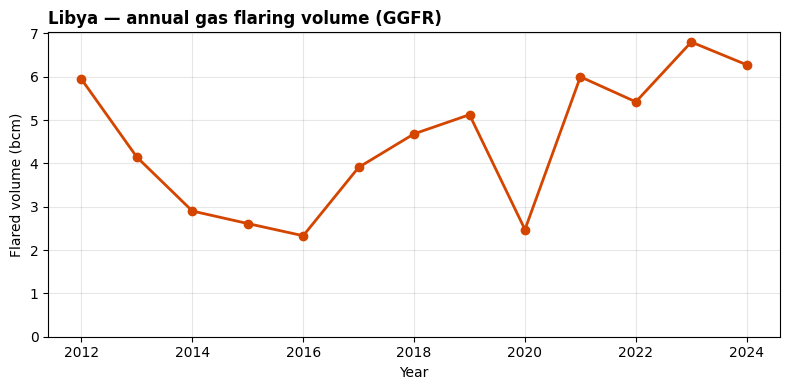

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(country_df["year"], country_df["bcm_flared"], marker="o", color="#d44500", linewidth=2)
ax.set_title("Libya — annual gas flaring volume (GGFR)", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Flared volume (bcm)")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


## 2. African context — top-5 producers in 2024


In [4]:
african_producers = pf.list_supported_countries()
top5 = (
    annual[(annual["country"].isin(african_producers)) & (annual["year"] == 2024)]
    .nlargest(5, "bcm_flared")
    .reset_index(drop=True)
)
top5


,country,year,bcm_flared
0,Algeria,2024,7.88203
1,Nigeria,2024,6.47956
2,Libya,2024,6.27505
3,Angola,2024,2.06090
4,Republic of Congo,2024,1.93604


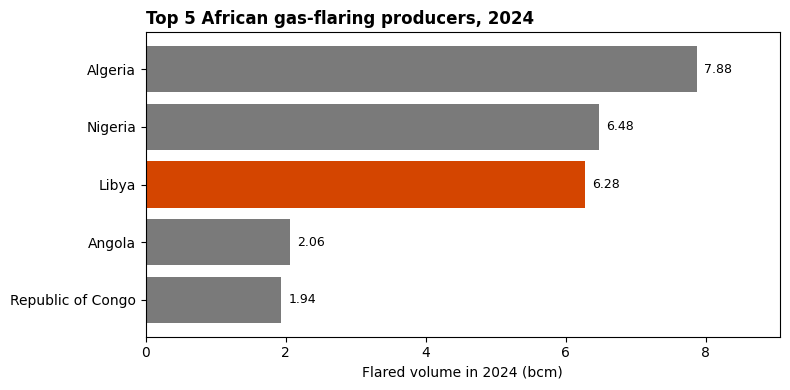

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
highlight = ["#d44500" if c == "Libya" else "#7a7a7a" for c in top5["country"][::-1]]
bars = ax.barh(top5["country"][::-1], top5["bcm_flared"][::-1], color=highlight)
ax.set_title("Top 5 African gas-flaring producers, 2024", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Flared volume in 2024 (bcm)")
for bar, val in zip(bars, top5["bcm_flared"][::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9)
ax.set_xlim(right=top5["bcm_flared"].max() * 1.15)
plt.tight_layout()
plt.show()


## 3. Per-flare detail — synthetic VNF stand-in

The real `pf.fetch_vnf_nightly()` call requires EOG OAuth 2.0
credentials (Client ID issued separately by EOG once the
academic license is signed). Until those arrive, we synthesise
a plausible Libya — Sirte basin + coastal terminals nightly detection set so the rest of the
pipeline can be exercised end-to-end. **Replace the next cell
with the real fetch once credentials are in hand:**

```python
import os
os.environ["EOG_CLIENT_ID"]     = "..."
os.environ["EOG_CLIENT_SECRET"] = "..."
os.environ["EOG_USERNAME"]      = "..."
os.environ["EOG_PASSWORD"]      = "..."
detections = pf.fetch_vnf_nightly("2024-08-15", satellite="snpp")
country_detections = pf.filter_country(detections, "Libya")
```


In [6]:
rng = np.random.default_rng(42)

# Approximate coordinates of major Libya — Sirte basin + coastal terminals flare facilities
# (public references; exact accuracy not relevant for the synthetic
# walkthrough, only that detections land inside the country bbox).
sites_truth = [
    ("Es Sider Terminal",    18.65,  30.62),
    ("Ras Lanuf",            18.55,  30.50),
    ("Marsa el Brega LNG",   19.62,  30.41),
    ("Sahabi",               19.20,  28.80),
    ("Hofra",                19.20,  29.10),
    ("El Sharara (Murzuq)",  12.20,  27.81),
]

records = []
for name, lon, lat in sites_truth:
    n = rng.integers(8, 16)  # 8-15 nightly observations per site
    for _ in range(n):
        records.append({
            "site_truth": name,
            "longitude": lon + rng.normal(0, 0.005),  # ~500m jitter
            "latitude":  lat + rng.normal(0, 0.005),
            "temperature_k":   max(1500, rng.normal(1850, 150)),
            "radiant_heat_mw": rng.uniform(20, 80),
            "obs_date": pd.Timestamp("2024-08-15") + pd.Timedelta(days=int(rng.integers(0, 14))),
        })
# Sprinkle in some wildfires for the classifier to reject.
for _ in range(15):
    records.append({
        "site_truth": "wildfire",
        "longitude": rng.uniform(10.0, 25.0),
        "latitude":  rng.uniform(30.0, 33.0),
        "temperature_k":   rng.normal(900, 100),
        "radiant_heat_mw": rng.uniform(5, 25),
        "obs_date": pd.Timestamp("2024-08-15") + pd.Timedelta(days=int(rng.integers(0, 14))),
    })

vnf_synthetic = pd.DataFrame(records)
print(f"Synthesised {len(vnf_synthetic)} detections "
      f"(mean temp {vnf_synthetic['temperature_k'].mean():.0f} K)")


Synthesised 80 detections (mean temp 1681 K)


### Classify, filter, cluster

Threshold-based classification (Elvidge et al., 2013) splits
detections into flares vs wildfires; greedy clustering rolls
co-located nightly detections into persistent flare sites.


In [7]:
classified = classify_detection_type(vnf_synthetic)
flares = classified[classified["detection_type"] == "flare"].copy()
sites = aggregate_to_sites(flares)

print(f"  Total detections:  {len(vnf_synthetic)}")
print(f"  Classified flares: {len(flares)}")
print(f"  Clustered sites:   {len(sites)} (truth: 6 facilities)")
sites


  Total detections:  80
  Classified flares: 65
  Clustered sites:   13 (truth: 6 facilities)


,site_id,longitude,latitude,n_detections,mean_rh_mw,total_rh_mw
0,5,19.200618,28.798914,12,51.018672,612.224062
1,2,19.620634,30.406544,11,49.252457,541.777030
2,1,18.547530,30.500694,9,49.617179,446.554615
3,0,18.649188,30.619875,8,47.774525,382.196198
4,12,12.198358,27.807852,8,49.847213,398.777701
5,8,19.199720,29.095623,7,45.120252,315.841761
6,11,12.204177,27.804527,3,71.535881,214.607643
7,6,19.206357,28.795473,2,37.523437,75.046873
8,3,19.611563,30.402764,1,77.713860,77.713860
9,4,19.620109,30.418009,1,25.066659,25.066659


In [8]:
volumes = estimate_flared_volume(sites, observation_days=14)
site_total_bcm = volumes["estimated_volume_bcm"].sum()
print(f"Sum of synthetic-site flared volume estimates: {site_total_bcm:.4f} bcm")
print("(Synthetic, not comparable to GGFR country-wide total — illustrative only.)")
volumes[["site_id", "longitude", "latitude", "n_detections", "estimated_volume_bcm"]]


Sum of synthetic-site flared volume estimates: 0.1323 bcm
(Synthetic, not comparable to GGFR country-wide total — illustrative only.)


,site_id,longitude,latitude,n_detections,estimated_volume_bcm
0,5,19.200618,28.798914,12,0.024892
1,2,19.620634,30.406544,11,0.022027
2,1,18.547530,30.500694,9,0.018156
3,0,18.649188,30.619875,8,0.015539
4,12,12.198358,27.807852,8,0.016213
5,8,19.199720,29.095623,7,0.012841
6,11,12.204177,27.804527,3,0.008725
7,6,19.206357,28.795473,2,0.003051
8,3,19.611563,30.402764,1,0.003160
9,4,19.620109,30.418009,1,0.001019


## 4. Headline number — Libya CO₂-equivalent, 2024

Using `volume_to_co2eq()` against the **GGFR-reported** Libya
2024 flared volume (not the synthetic per-site sum), under three
published methane-slip assumptions.


In [9]:
country_2024_bcm = float(country_df.loc[country_df["year"] == 2024, "bcm_flared"].iloc[0])

scenarios = [
    (0.02, "IPCC AR6 default"),
    (0.05, "pyflare default / Plant et al. 2022 mid"),
    (0.09, "Plant et al. 2022 upper bound"),
]

rows = []
for slip, label in scenarios:
    mt = volume_to_co2eq(country_2024_bcm, slip)
    rows.append({"slip": slip, "source": label, "MtCO2e": round(mt, 2)})

headline = pd.DataFrame(rows)
print(f"Libya flared volume (GGFR 2024): {country_2024_bcm:.2f} bcm")
print()
headline


Libya flared volume (GGFR 2024): 6.28 bcm



,slip,source,MtCO2e
0,0.02,IPCC AR6 default,18.36
1,0.05,pyflare default / Plant et al. 2022 mid,21.91
2,0.09,Plant et al. 2022 upper bound,26.63


### Poster framing candidate

> **Libya's 2024 gas flaring translates to a range of
> megatonnes of CO₂-equivalent emissions per year, depending
> on which methane slip assumption you adopt. The spread is
> itself the argument for satellite measurement: the answer
> is not in dispute by an order of magnitude, but the
> difference between the IPCC AR6 default (2 %) and recent
> satellite-derived slip rates (5–9 %) drives the headline.**

The defensible quote for the poster is the range, with the
slip choice made explicit. Reviewers from atmospheric
chemistry will nod; reviewers from advocacy will appreciate
the upper bound.

## 5. Next steps

- Replace the synthetic VNF cell with `pf.fetch_vnf_nightly()`
  once the EOG OAuth credentials arrive. **Before re-publishing
  this notebook with real VNF outputs, confirm:** (a) the
  displayed year is cleared at
  https://eogdata.mines.edu/products/vnf/global_gas_flare.html,
  (b) any temporal display is aggregated to weekly minimum,
  and (c) the data-attribution cell above is in place.
- Cross-validate the synthetic-site clustering against
  ground-truth facility coordinates (the `sites_truth` list
  above) once VNF detections are real.

---

*Source: VIIRS Nightfire, Colorado School of Mines.* (Applies
once the synthetic VNF block above is replaced with real EOG
data.)
